# A/B Testing Fundamentals: Proportions and Means

## Overview

An A/B test is a randomised experiment comparing two conditions. The same logic applies whether the outcome is binary (conversion, response, presence/absence) or continuous (richness, concentration, score). The workflow is identical in both cases:

1. **Pre-specify:** primary outcome, MDE, α, power → compute required n
2. **Randomise** units to A and B
3. **Collect** data to the pre-specified n (do not peek)
4. **Test** using the appropriate test
5. **Report** the effect size with confidence interval, not just p-value

**Test selection:**

| Outcome | Equal variance? | Test |
|---|---|---|
| Continuous | Assumed equal | Student's t-test |
| Continuous | Not assumed | Welch's t-test (default in R) |
| Binary / proportions | — | Two-proportion z-test |
| Count | Overdispersed | Negative binomial regression |

**Effect size reporting:**
- Continuous: Cohen's d, mean difference with CI
- Binary: absolute risk difference, relative risk, odds ratio — all three; never OR alone

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(infer)         # tidy hypothesis testing framework
library(effectsize)    # cohens_d(), interpret_d()
library(pwr)
library(patchwork)

set.seed(42)

# ── Scenario A: Continuous outcome — species richness ─────────────────────────
# Control: riparian zones without restoration; Treatment: restored zones
n_per <- 65   # from power analysis: d=0.35, α=0.05, power=0.80

cont_data <- tibble(
  group    = rep(c("control","treatment"), each=n_per),
  richness = c(rnorm(n_per, mean=18, sd=5),
               rnorm(n_per, mean=20, sd=5.2))
)

# ── Scenario B: Binary outcome — species presence ─────────────────────────────
# Control: p=0.30 presence; Treatment: p=0.42 presence
n_bin <- 200
bin_data <- tibble(
  group   = rep(c("control","treatment"), each=n_bin),
  present = c(rbinom(n_bin, 1, 0.30),
              rbinom(n_bin, 1, 0.42))
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'infer' was built under R version 4.4.3"
Warning message:
"package 'effectsize' was built under R version 4

---

## Continuous Outcome: Welch's t-Test

# A tibble: 2 × 5
  group         n  mean    sd    se
  <chr>     <int> <dbl> <dbl> <dbl>
1 control      65  18.0  5.63 0.699
2 treatment    65  19.7  4.95 0.614

	Welch Two Sample t-test

data:  richness by group
t = -1.8608, df = 125.95, p-value = 0.0651
alternative hypothesis: true difference in means between group control and group treatment is not equal to 0
95 percent confidence interval:
 -3.5728206  0.1099306
sample estimates:
  mean in group control mean in group treatment 
               17.95943                19.69088 


Cohen's d = -0.326 [-0.672, 0.020] — small


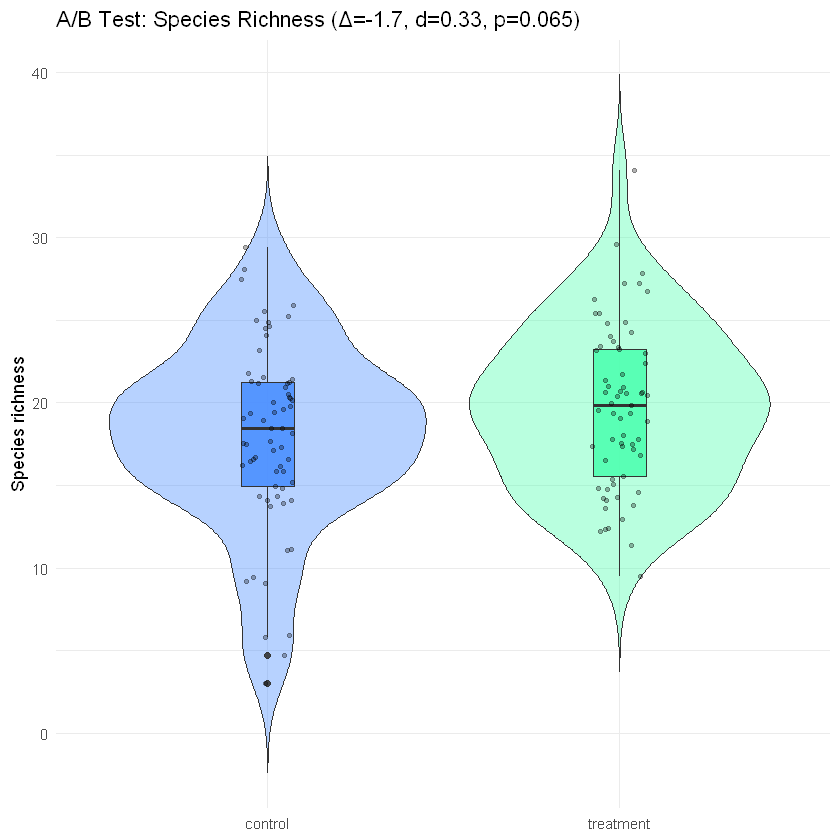

In [3]:
# ── Descriptive summary ───────────────────────────────────────────────────────
cont_summary <- cont_data %>%
  group_by(group) %>%
  summarise(n = n(), mean = mean(richness), sd = sd(richness),
            se = sd / sqrt(n), .groups = "drop")
print(cont_summary)

# ── Welch's t-test ────────────────────────────────────────────────────────────
t_result <- t.test(richness ~ group, data = cont_data,
                   var.equal = FALSE, alternative = "two.sided")
print(t_result)

# ── Effect size: Cohen's d ────────────────────────────────────────────────────
d_result <- effectsize::cohens_d(richness ~ group, data = cont_data)
cat(sprintf("\nCohen's d = %.3f [%.3f, %.3f] — %s\n",
            d_result$Cohens_d, d_result$CI_low, d_result$CI_high,
            effectsize::interpret_cohens_d(d_result$Cohens_d)))  # renamed

# ── Visualisation ─────────────────────────────────────────────────────────────
p_cont <- ggplot(cont_data, aes(x = group, y = richness, fill = group)) +
  geom_violin(alpha = 0.4, trim = FALSE) +
  geom_boxplot(width = 0.15, alpha = 0.9) +
  geom_jitter(width = 0.08, alpha = 0.3, size = 1) +
  scale_fill_manual(values = c(control = "#4a8fff", treatment = "#4fffb0"),
                    guide = "none") +
  labs(title = sprintf("A/B Test: Species Richness (Δ=%.1f, d=%.2f, p=%.3f)",
                       diff(rev(cont_summary$mean)),
                       abs(d_result$Cohens_d), t_result$p.value),
       x = NULL, y = "Species richness") +
  theme_minimal()
p_cont

---

## Binary Outcome: Two-Proportion Test

In [4]:
# Observed proportions
prop_summary <- bin_data %>%
  group_by(group) %>%
  summarise(n=n(), successes=sum(present), proportion=mean(present), .groups="drop")
print(prop_summary)

# ── Two-proportion z-test ─────────────────────────────────────────────────────
prop_test <- prop.test(
  x = prop_summary$successes,
  n = prop_summary$n,
  alternative = "two.sided",
  correct     = FALSE   # no Yates correction for large n
)
print(prop_test)

# ── Effect sizes: ARD, RR, OR ─────────────────────────────────────────────────
p_ctrl <- prop_summary$proportion[prop_summary$group=="control"]
p_trt  <- prop_summary$proportion[prop_summary$group=="treatment"]

ARD <- p_trt - p_ctrl                      # absolute risk difference
RR  <- p_trt / p_ctrl                      # relative risk
OR  <- (p_trt/(1-p_trt)) / (p_ctrl/(1-p_ctrl))  # odds ratio

# CI for ARD using normal approximation
se_ARD <- sqrt(p_trt*(1-p_trt)/n_bin + p_ctrl*(1-p_ctrl)/n_bin)
ard_ci <- ARD + c(-1,1)*1.96*se_ARD

cat(sprintf("\nAbsolute risk difference: %.3f [%.3f, %.3f]\n", ARD, ard_ci[1], ard_ci[2]))
cat(sprintf("Relative risk:            %.3f\n", RR))
cat(sprintf("Odds ratio:               %.3f\n", OR))
cat("\nAlways report ARD alongside RR/OR — relative measures are misleading without the baseline rate.")

# A tibble: 2 × 4
  group         n successes proportion
  <chr>     <int>     <int>      <dbl>
1 control     200        53      0.265
2 treatment   200        71      0.355

	2-sample test for equality of proportions without continuity correction

data:  prop_summary$successes out of prop_summary$n
X-squared = 3.7868, df = 1, p-value = 0.05166
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.1802169101  0.0002169101
sample estimates:
prop 1 prop 2 
 0.265  0.355 


Absolute risk difference: 0.090 [-0.000, 0.180]
Relative risk:            1.340
Odds ratio:               1.527

Always report ARD alongside RR/OR — relative measures are misleading without the baseline rate.

---

## Permutation-Based Testing with `infer`

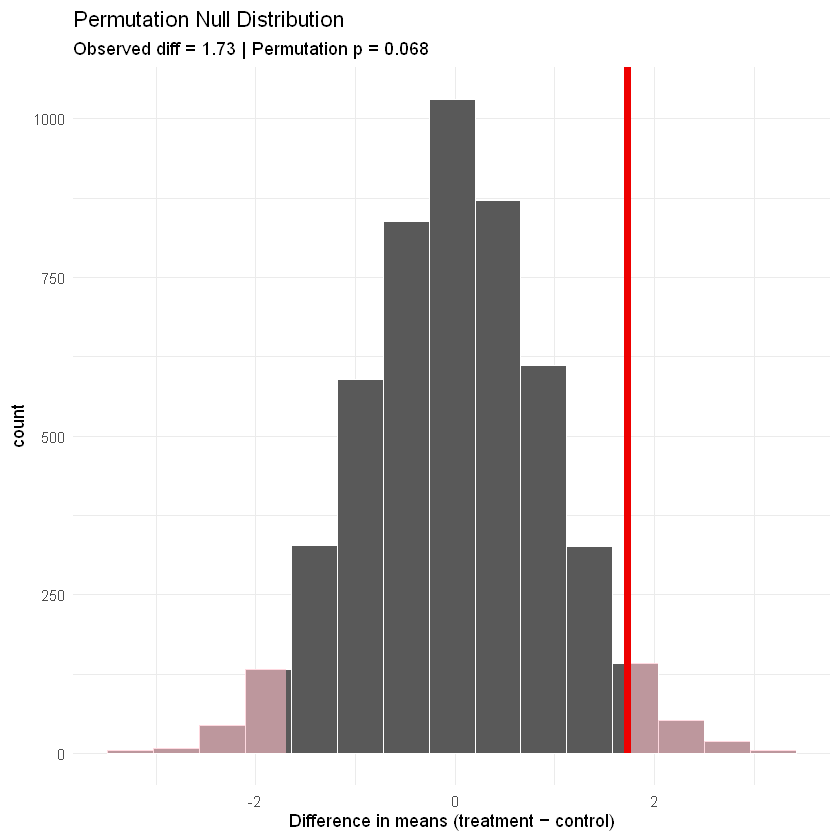

In [5]:
# infer: tidy, transparent pipeline for hypothesis testing
# Permutation test: no distributional assumptions required

obs_stat <- cont_data %>%
  infer::specify(richness ~ group) %>%
  infer::calculate(stat="diff in means", order=c("treatment","control"))

null_dist <- cont_data %>%
  infer::specify(richness ~ group) %>%
  infer::hypothesize(null="independence") %>%
  infer::generate(reps=5000, type="permute") %>%
  infer::calculate(stat="diff in means", order=c("treatment","control"))

p_value_perm <- null_dist %>%
  infer::get_p_value(obs_stat=obs_stat, direction="two-sided")

infer::visualize(null_dist) +
  infer::shade_p_value(obs_stat=obs_stat, direction="two-sided") +
  labs(title="Permutation Null Distribution",
       subtitle=sprintf("Observed diff = %.2f | Permutation p = %.3f",
                        obs_stat$stat, p_value_perm$p_value),
       x="Difference in means (treatment − control)") +
  theme_minimal()

---

## Common Pitfalls

**1. Reporting only p-values without effect sizes and confidence intervals**  
A p-value answers "is there evidence of any effect?" — not "how large is the effect?" A significant p=0.03 with d=0.08 and CI [0.01, 0.15] describes a statistically detectable but practically negligible difference. Always report the effect size, its confidence interval, and a plain-language description of what the difference means in context.

**2. Reporting only relative risk or odds ratio for binary outcomes**  
A relative risk of 2.0 sounds impressive but means very different things depending on the baseline: going from 0.001% to 0.002% is the same RR as going from 30% to 60%. Always report the absolute risk difference alongside RR and OR. For rare outcomes (p < 0.1), OR approximates RR; for common outcomes they diverge substantially.

**3. Using Student's t-test (equal variances) by default**  
Student's t-test assumes equal variances across groups. Welch's t-test (`var.equal=FALSE`, the R default) does not — and has almost identical power when variances are equal. There is no reason to use Student's t-test in practice. Always use Welch's.

**4. Peeking at results before the pre-specified sample size is reached**  
Running a t-test every week and stopping when p < 0.05 inflates Type I error dramatically — the actual α can exceed 20% even when the nominal level is 5%. Either commit to the pre-specified n and run the test once, or use a sequential testing framework with appropriate α spending. See `sequential_testing.ipynb`.

**5. Treating non-significant results as evidence of no effect**  
A non-significant A/B test does not mean the two conditions are equivalent — it means the data are consistent with the null, given the study's power. Report the confidence interval for the effect size: if the entire CI falls within the range of practically unimportant effects, you have reasonable evidence of equivalence. If the CI is wide, the study was underpowered.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*